## Imports

In [1]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

## Define experimental parameters

In [2]:
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=None,  # Use interval mode
    initial_time=-5.0/inverse_pulse_width,
    final_time=5.0/inverse_pulse_width,
    time_interval=1.0/inverse_pulse_width,
    initial_time_uncertainty=0.0/inverse_pulse_width
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.00,  
    dephasing = 0.00,      
    relaxation = 0.00
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config,
    random_seed=42
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavity levels:             2
  Qubit levels:              2
  Field levels:              2
  Total dimension:           8
  Status:               VALID
PHYSICAL CONSTANTS
  Chi:                    0.0942
  Photon cavity coupling: 0.1885
  Inverse pulse width:    0.0188
  Status:               VALID
MEASUREMENT PROTOCOL
  Mode:                 Interval-based
  Initial time:         -265.2582
  Final time:           265.2582
  Time interval:         53.0516
  Number of measurements:     11
  Computed times:       [np.float64(-265.25823848649225), np.float64(-212.2065907891938), np.float64(-159.15494309189535), np.float64(-106.1032953945969), np.float64(-53.05164769729845), np.float64(0.0), np.float64(53.05164769729845), np.float64(106.1032953945969), np.float64(159.15494309189535), np.float64(212.2065907891938), np.float64(265.25823848649225)]
  Status:               VALID
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:      0.0000

## Define trainable parameters

In [3]:
parameters = TrainableParameters()
# Add rotation angles (always needed)
parameters.add_rotation_angles(
    names=['theta1', 'theta2'],
    initial_values=[np.pi/2, -np.pi/2],
    trainable=[False, False]
)

# Add trainable time_interval
# NOTE: This will OVERRIDE the value from experimental_parameters
parameters.add_measurement_interval(
    names='time_interval',
    initial_values=1.0/inverse_pulse_width,      # Starting value for optimization
    min_interval=0.000001,        # Minimum allowed value (must be > 0)
    trainable=True           # Enable optimization
)

print(parameters)

Trainable Parameters: 3
  Rotation Angles:
    theta1: 1.5708 rad (90.00°) [FIXED]
    theta2: -1.5708 rad (-90.00°) [FIXED]
  Measurement Times:
    time_interval: 53.0516


## Define experiment

In [4]:
experiment = SingleQubitExperiment(exp_parameters, parameters)

## Test Single Simulation

In [5]:
results = experiment.run_simulation(batch_size=1)
print(results)

MODE: Single Simulation
  Current Parameters:
     theta1: 1.570796 rad (90.00°)
     theta2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.973022
     P(without photon): 0.000000
     Contrast:          0.973022


## Run Optimization

In [6]:
history = experiment.optimize(
    num_steps=70,
    verbose=True,
    tolerance=1e-7
)

Configuration:
    Max iterations: 70
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: theta1=1.571 rad [FIXED], theta2=-1.571 rad [FIXED]
    Initial time interval: 53.051648
    Optimizer: GradientTransformationExtraArgs
Step  theta1      theta2      Δt          Contrast    Grad Norm
----------------------------------------------------------------------
[0. 0. 0.]
0     1.570796    -1.570796   53.051648   0.973022    0.00e+00    
Final gradient norm: 0.00e+00
Best sensing contrast: 0.973022
Best parameters: theta1=1.571 rad, theta2=-1.571 rad, Δt=53.051648


In [7]:
print(history)

MODE: Optimization
     Total iterations: 1
     Best epoch:        1
     Converged: True
     Final gradient norm: 0.000000e+00
  Best Parameters:
     theta1: 1.570796 rad (90.00°)
     theta2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.973022
     P(without photon): 0.000000
     Contrast:          0.973022


## Visualization Dashboard

c:\users\simon\code\quantum-sensing-qml\src\qsopt\utils\visualization.py:268: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


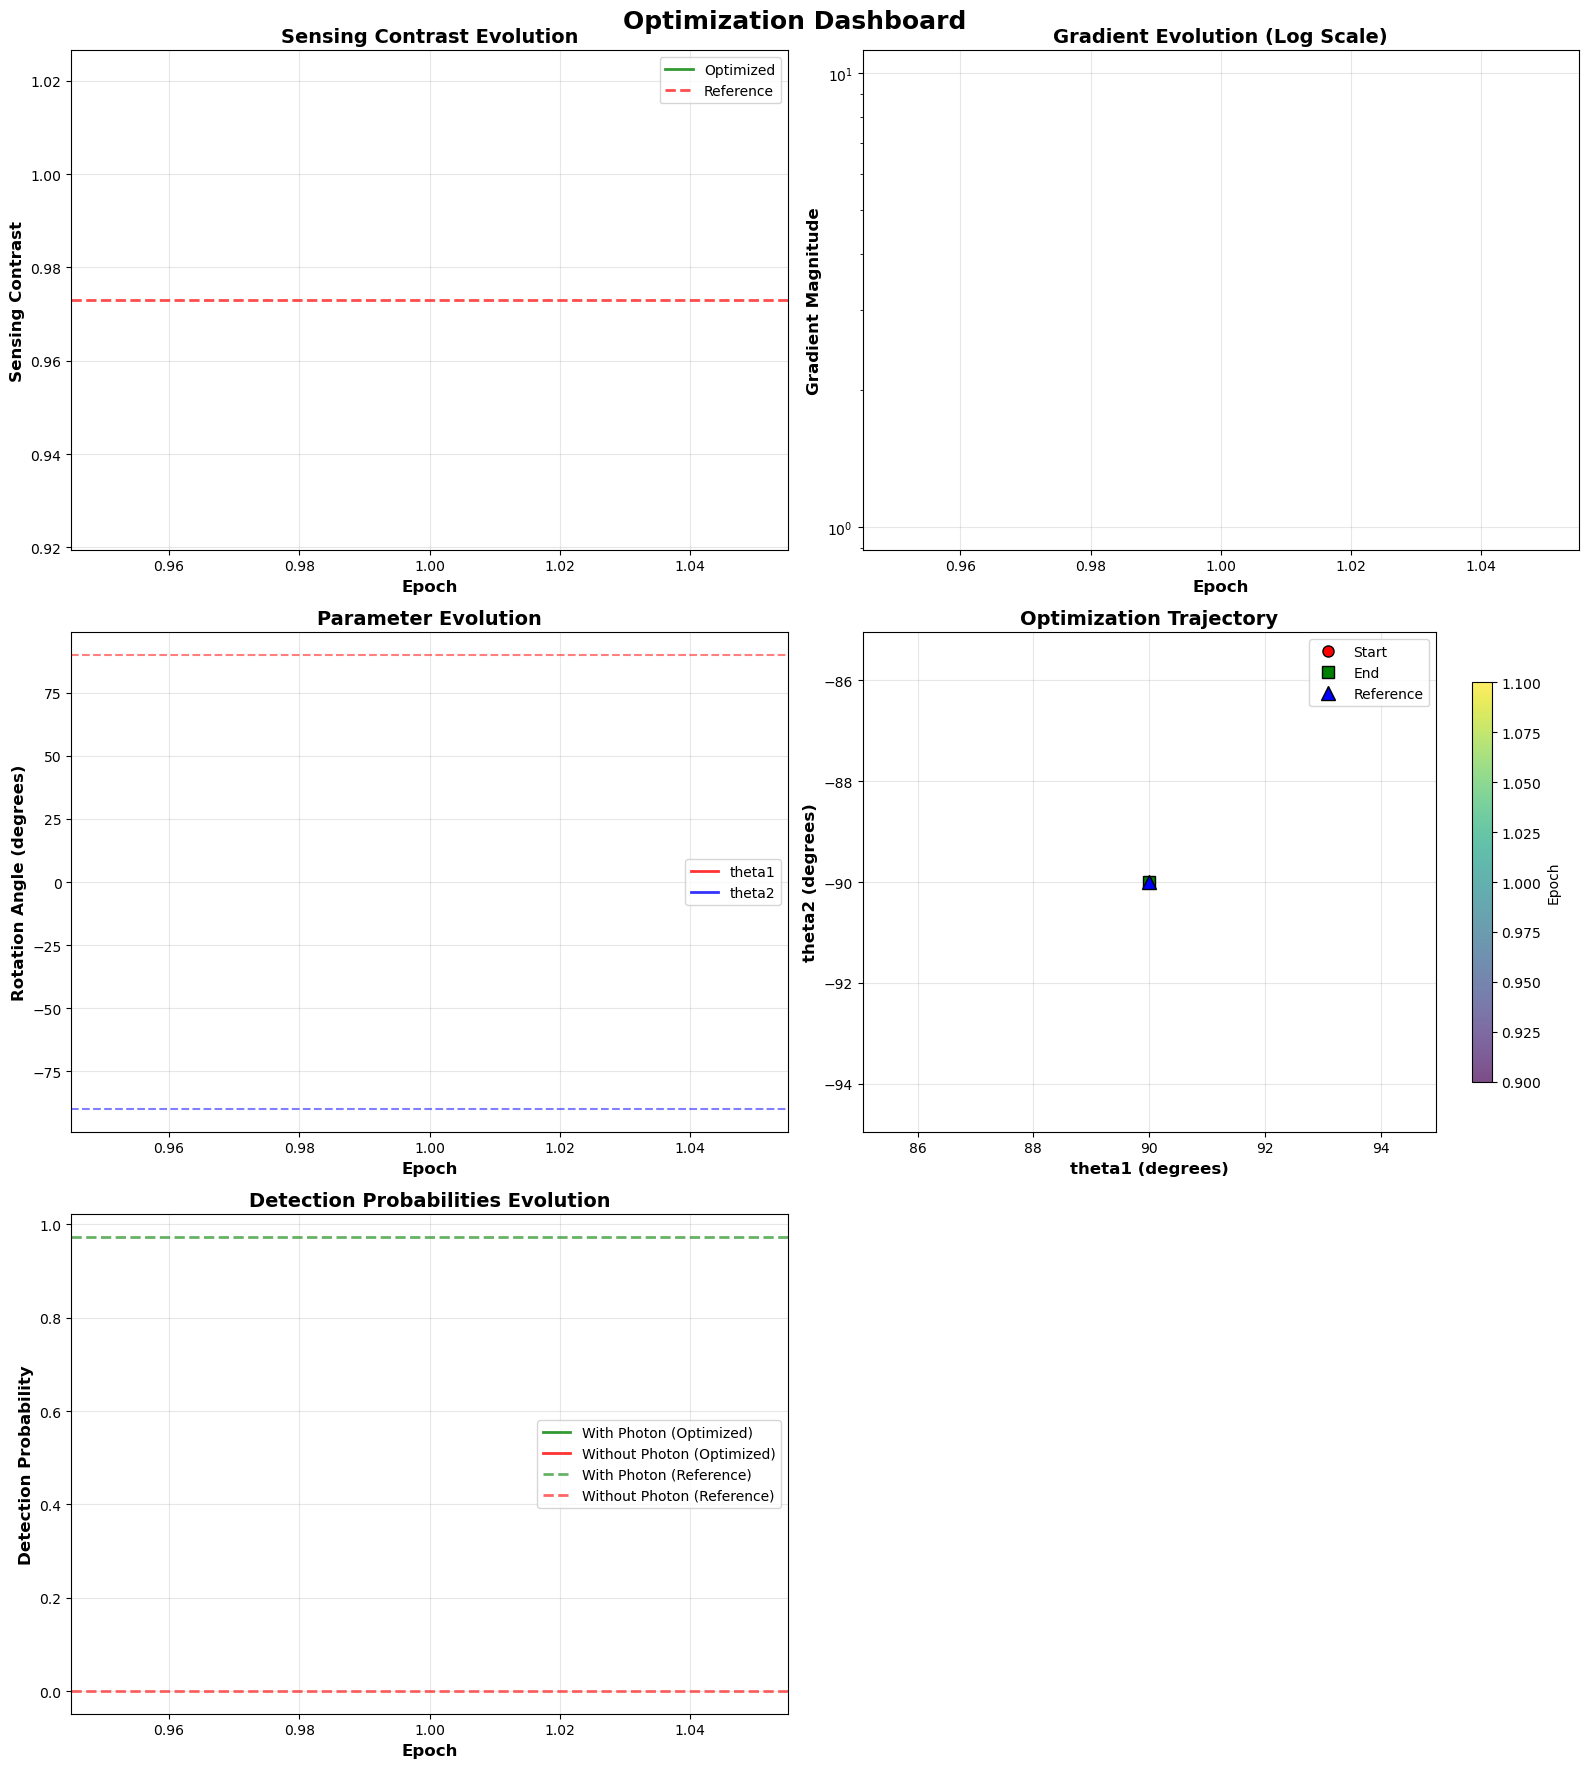

In [8]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    save_path='results/opt_dashboard.pdf'  # Save to file
)

plt.show()